# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Adrià Valmaña Perez
* Username: avalmana
* Student number: s6217338
* Group (AS1, etc.): AS5

-----

In [4]:
from matplotlib.pyplot import imshow

totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

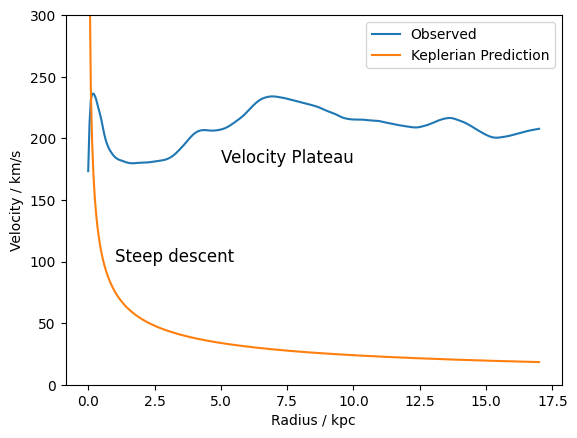

The keplerian prediction does not match up at all with the observed values, which seem to remain constant all along. This could hint to the existence of more matter than we expect or an incorrect theory of gravity


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.constants import G, GM_sun

M = 2e10 * GM_sun.value
rotcur = '/Users/taiga/Desktop/RUG/2025–26/BlocII/ProgNum/PROGNUM-repo/Task5/rotcur.dat.txt'
radii, rotation_velocities = np.loadtxt(rotcur, unpack=True)     # in kpc and km/s

r_km = radii * 30856775812799584
v = ( (G.value * M) / r_km ) ** .5

np.savetxt('keplerian_curve.txt', v)
kep_curve = np.loadtxt('keplerian_curve.txt')

plt.plot(radii, rotation_velocities,
         label='Observed')
plt.plot(radii, kep_curve,
         label='Keplerian Prediction')
plt.annotate('Velocity Plateau',
             (5, 180),
             fontsize='large',)
plt.annotate('Steep descent',
             (1, 100),
             fontsize='large')
plt.ylim(0, 300)
plt.xlabel('Radius / kpc')
plt.ylabel('Velocity / km/s')
plt.legend()
plt.show()

print('The keplerian prediction does not match up at all with the observed values, which seem to remain constant all along. This could hint to the existence of more matter than we expect or an incorrect theory of gravity')

In [5]:
# Leave unaltered
totalpoints += 4
currentpoints += 3.5

<div class="warning" style='background-color:#FBD5D9; color: #B21129; border-left: solid #E20035 6px; border-radius: 4px; padding:2em;'>
<span>
    <b>0.5pt deducted</b>, when calculating v, make sure all quantities are in the same units, including G.

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

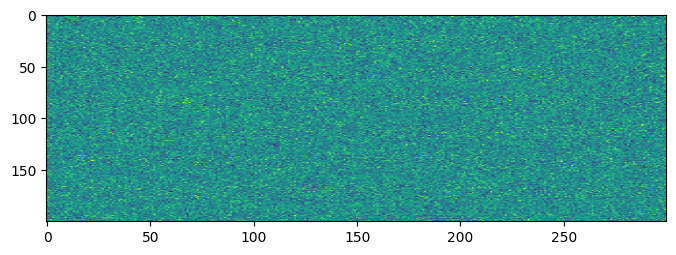

In [4]:
import numpy as np
import matplotlib.pyplot as plt

Nx = 200
Ny = 300
data = np.random.normal(loc=0, scale=1, size=(Nx, Ny))

plt.figure(figsize=(8, 4))
plt.imshow(data, aspect='.5')
plt.show()

In [6]:
# Leave unaltered
totalpoints += 3
currentpoints += 1.5

<div class="warning" style='background-color:#FBD5D9; color: #B21129; border-left: solid #E20035 6px; border-radius: 4px; padding:2em;'>
<span>
    <b>1.5pt deducted</b>, no statistics and no histogram.

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

A = 18.84955592153876, P = 14.475501247630977
Ellipse(xy=(0, 0),  width=4.0, height=6.0, angle=0)


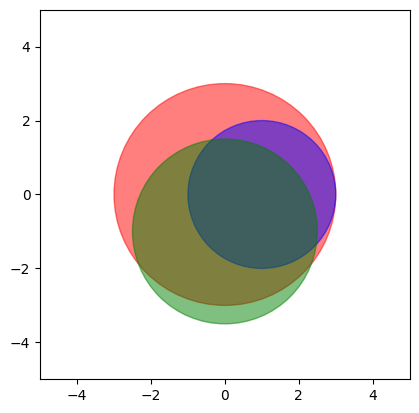

In [6]:
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import numpy as np

class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle=0, **args):
        assert(semi_major >= semi_minor)
        XY = (xc, yc)
        angle_mpl = position_angle
        height = 2.0*semi_major
        width  = 2.0*semi_minor
        super().__init__(XY, width, height, angle=angle_mpl, **args)
        self.xc = xc
        self.yc = yc
        self.semi_major = semi_major
        self.semi_minor = semi_minor
        self.position_angle = position_angle
        self.XY = XY
        self.angle_mpl = angle_mpl
        self.height = height
        self.width = width

    def __str__(self):
        s = f'Ellipse(xy={self.XY},  width={self.width}, height={self.height}, angle={self.angle_mpl})'
        return s

    def area(self):
        return np.pi * self.semi_major * self.semi_minor

    def perimeter(self):
        a = self.semi_major
        b = self.semi_minor
        return np.pi * (3 * (a + b) - np.sqrt((3 * a + a) * (a + 3 * b)))

class MyCircle(AstroEllipse):
    def __init__(self, centre, radius, **args):
        xc, yc = centre
        semi_major = semi_minor = radius
        super().__init__(xc, yc, semi_major, semi_minor, **args)
        self.centre = centre
        self.radius = radius


example_ellispe = AstroEllipse(0, 0, 3, 2)
print(f'A = {example_ellispe.area()}, P = {example_ellispe.perimeter()}')
print(example_ellispe)

fig, ax = plt.subplots()

c1 = MyCircle((0, 0), 3, color='red', alpha=0.5)
c2 = MyCircle((1, 0), 2, color='blue', alpha=0.5)
c3 = MyCircle((0, -1), 2.5, color='green', alpha=0.5)

ax.add_patch(c1)
ax.add_patch(c2)
ax.add_patch(c3)

ax.set_aspect('equal')
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)

plt.show()

In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 6

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

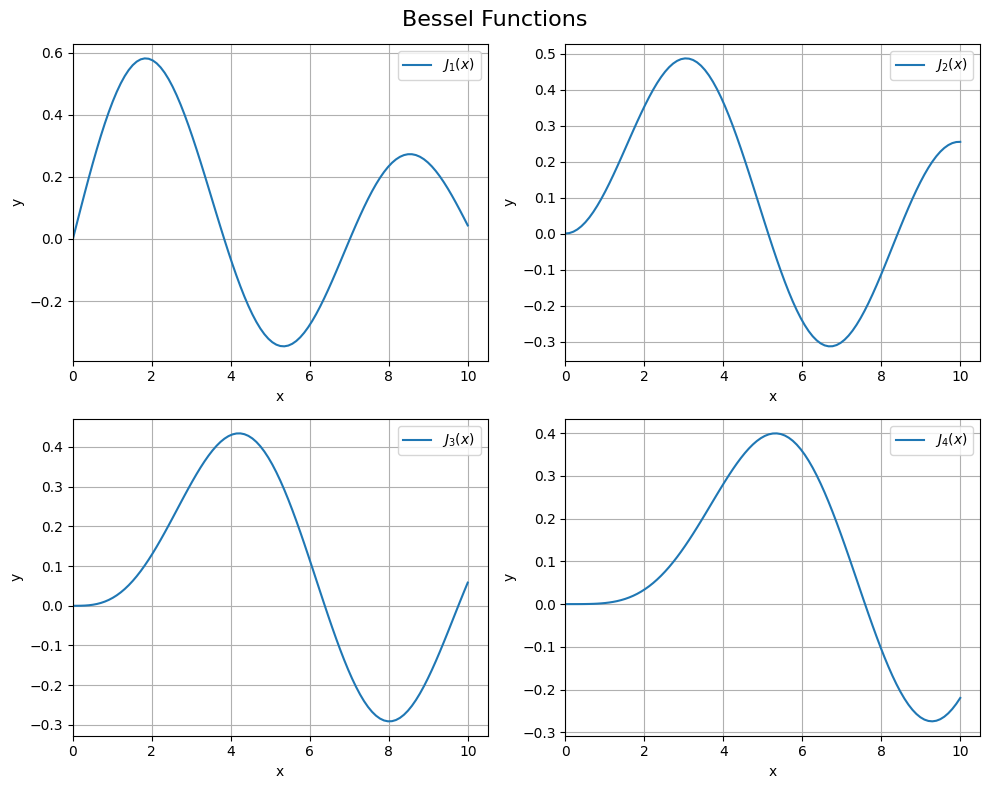

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv

class Bessel:
    def __init__(self, a, x):
        self.a = a
        self.x = x
        self.y = jv(a[:, None], x)

    def plot(self):
        fig, axs = plt.subplots(2, 2, figsize=(10, 8))

        axs = axs.flatten()
        for i, ax in enumerate(axs):
            a = int(self.a[i])
            ax.plot(self.x, self.y[i], label=f'$J_{a}(x)$')
            ax.set_xlabel('x')
            ax.set_ylabel('y')
            ax.set_xlim(0, 10.5)
            ax.legend()
            ax.grid(True)

        fig.suptitle('Bessel Functions', fontsize=16)
        fig.tight_layout()
        plt.show()
        fig.savefig('bessel.png')

a = np.linspace(1, 4, 4)
x = np.linspace(0, 10, 100)

J = Bessel(a, x)
J.plot()

![bessel.png](bessel.png)

In [8]:
# Leave unaltered
totalpoints += 3
currentpoints += 3

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

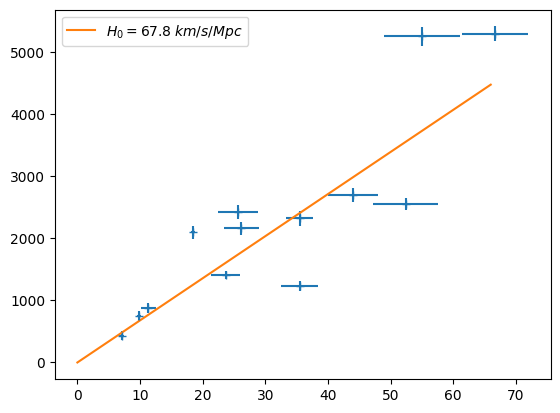

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

class PlotGalaxies:
    def __init__(self, x, y, error_x, error_y, **args):
        self.x = x
        self.y = y
        self.error_x = error_x
        self.error_y = error_y

    def plot(self):
        fig, ax = plt.subplots()
        ax.errorbar(self.x, self.y, xerr=self.error_x, yerr=self.error_y, fmt='+')
        xaxis = np.linspace(0, int(max(self.x)), 100)
        H_0 = 67.8
        plt.plot(xaxis, xaxis * H_0, label='$H_0 = 67.8 \; km/s/Mpc$')
        plt.legend()
        plt.show()

data = [
    18.49, 2094.75, 0.3, 100,
    35.48, 2320.87, 2.2, 120,
    35.48, 1224.9, 3.0, 80,
    11.34, 872.13, 1.2, 80,
    7.12, 432.2, 0.4, 70,
    9.82, 751, 0.3, 75,
    23.66, 1410, 2.3, 70,
    44, 2700, 4.0, 110,
    66.7, 5292, 5.3, 120,
    52.4, 2550, 5.2, 100,
    55, 5253, 6.1, 150,
    25.6, 2419, 3.2, 110,
    26.19, 2158, 2.8, 110
]

d = data[::4]
v = data[1::4]
error_d = data[2::4]
error_v = data[3::4]

G = PlotGalaxies(d, v, error_d, error_v)
G.plot()

In [9]:
# Leave unaltered
totalpoints += 2
currentpoints += 2

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [10]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 16.0.  Task Grade = 8.9
